# 06 · Paradigm-shift smoke test (v2)

The first end-to-end notebook against the v2 model (PDF 13 May 2026).
We run a small population through a step-schedule paradigm shift —
truth $\theta^*$ jumps from 0 (Newtonian) to $\theta^*_{\text{post}}$
(relativistic) at $t = t^*$ — and watch:

- the population-mean posterior $\bar\mu(t)$ rise toward the new truth,
- the population-mean posterior precision $\bar\tau(t)$ grow as
  evidence accumulates (PDF §5 mechanism iii: Bayesian rigidity),
- the trust matrix $\Gamma$ specialise as agents differentiate
  high-surprisal from low-surprisal neighbours.

This is a *smoke test*: the goal is "the model runs and the qualitative
dynamics are sane", not paper-grade figures. Full E1 / E2 in follow-up
notebooks.

## §0 · Setup

`build(ModelConfig(...))` constructs the population in one call. The
default `WorldConfig` uses $h_0(x) = x/2$, $h_1(x) = x^3$, $\sigma = 1$,
matching the relativistic-correction case in PDF Fig 1. The default
`PolicyConfig` x-grid is $\{0.1, 0.3, 1.0, 2.0, 3.0\}$ with quadratic
cost — agents that are still uncertain pick high-$x$ to discriminate;
confident agents pick cheap low-$x$ confirmations.

Step schedule: $\theta^* = 0$ until $t = 30$, then $\theta^* = 1$ for
the remaining 80 steps.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    build, ModelConfig, WorldConfig, PolicyConfig, TrustConfig, NetworkConfig,
    History,
)
from src.viz import cluster_layout, static_strip

sns.set_theme(context='notebook', style='whitegrid')

cfg = ModelConfig(
    n_agents=60, mu_0=0.0, tau_0=1.0, seed=0,
    world=WorldConfig(
        theta_star_pre=0.0, theta_star_post=1.0,
        schedule='step', schedule_t_shift=30,
    ),
    policy=PolicyConfig(),         # defaults: x_grid={0.1..3.0}, quadratic cost
    trust=TrustConfig(rho=0.99, learning=True),
    network=NetworkConfig(kind='watts_strogatz', mean_degree=4, rewiring_p=0.1),
)
pop = build(cfg)
print(repr(pop))
print(f'cfg.world.h0 = x/2, h1 = x^{cfg.world.h1_k}, sigma = {cfg.world.sigma}')
print(f"theta* schedule: {cfg.world.schedule!r}, shift at t = {cfg.world.schedule_t_shift}")
print(f"x_grid = {cfg.policy.x_grid}, cost_kind = {cfg.policy.cost_kind!r}")


Population(N=60, edges=120, mu_mean=+0.000, tau_mean=1.000, gamma_mean=0.2000)
cfg.world.h0 = x/2, h1 = x^3, sigma = 1.0
theta* schedule: 'step', shift at t = 30
x_grid = (0.1, 0.3, 1.0, 2.0, 3.0), cost_kind = 'quadratic'


## §1 · Rollout

Run 110 steps. Snapshot $(μ, τ, Γ, α, β)$ every 2 steps. Record per-step
$\theta^*(t)$, chosen $x_i$ distribution, observed $o_i$ distribution.

In [2]:
T = 200
hist = History()
thetas = []
x_chosen_per_step = []
o_obs_per_step = []

hist.snap(pop, every=2)
for t in range(T):
    pop, out = pop.step(t)
    thetas.append(out['theta_star'])
    x_chosen_per_step.append(out['x_chosen'])
    o_obs_per_step.append(out['o_obs'])
    hist.snap(pop, every=2)

thetas = np.array(thetas)
x_chosen_arr = np.stack(x_chosen_per_step)         # (T, N)
o_obs_arr = np.stack(o_obs_per_step)               # (T, N)
snapshots = hist.as_snapshots()
print(f'collected {len(snapshots)} snapshots over T={T} steps')
print(f'final pop: {repr(pop)}')


collected 101 snapshots over T=200 steps
final pop: Population(N=60, edges=120, mu_mean=+0.725, tau_mean=195.883, gamma_mean=0.2000)


## §2 · Population trajectory

Four panels:

1. $\bar\mu(t) \pm \text{std}$ — population mean posterior over $\theta$,
   with $\theta^*(t)$ overlaid as the dotted line. After the shift at
   $t = 30$, $\bar\mu$ should rise toward 1.0.
2. $\bar\tau(t)$ — population mean posterior precision. Monotone
   non-decreasing (PDF mechanism iii).
3. Histogram of $x_i$ chosen per step, stacked-area form. As $\bar\tau$
   grows, the policy shifts toward cheap low-$x$ confirmations.
4. The diagonal $\bar{\gamma_{ii}}$ (self-trust) and the off-diagonal
   $\bar{\gamma_{ij}}$ (neighbour trust) over time. The self/social split
   that v1's scalar $d_i$ used to encode is now a direct read-off of $Γ$.

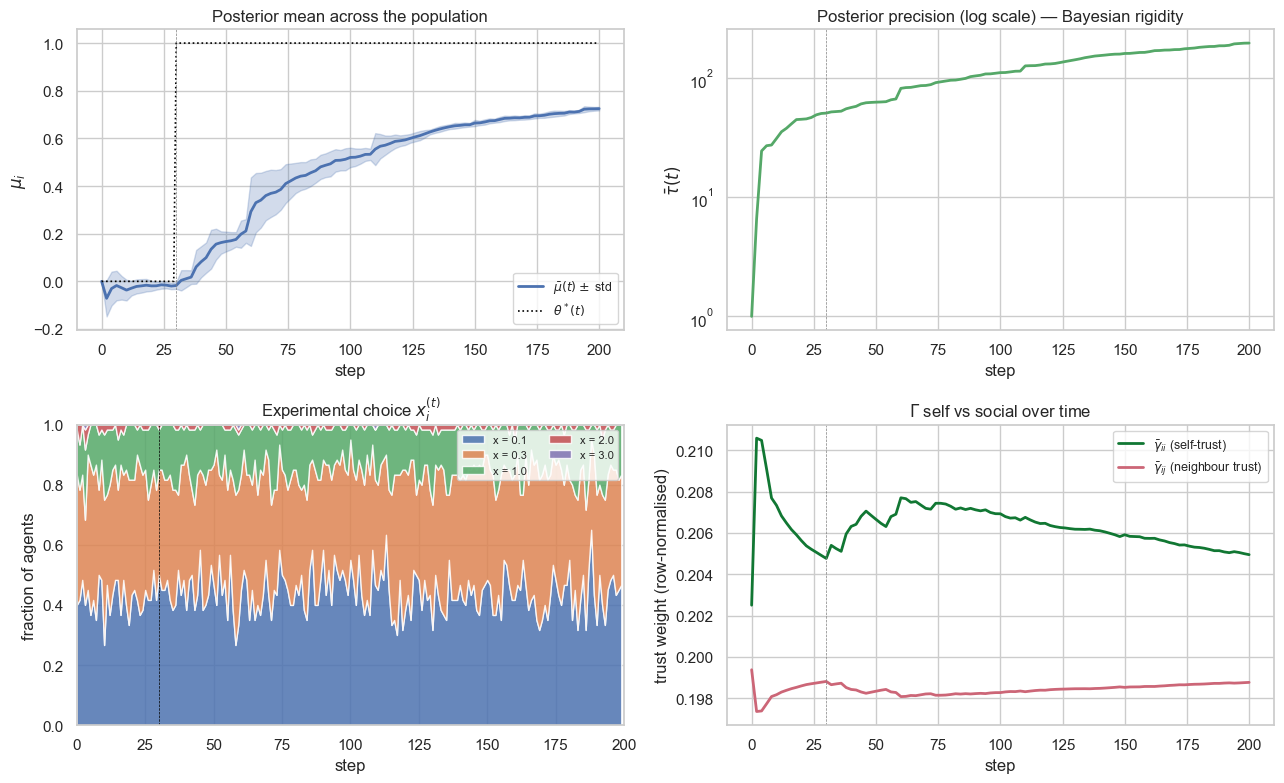

theta*_post = 1.0
mu at t = t_shift - 1:   -0.020
mu at t = t_shift + 30:  +0.292    (early post-shift)
mu at t = t_shift + 100: +0.619   (mid post-shift)
mu at t = T - 1:         +0.725    (end of run)
tau growth: 1.00  ->  195.88
gamma self / social at t=0:   0.202  /  0.199
gamma self / social at t=end: 0.205  /  0.199


In [3]:
mu_t = np.stack([s['mu'] for s in snapshots])         # (T_snap, N)
tau_t = np.stack([s['tau'] for s in snapshots])
gamma_t = np.stack([s['gamma'] for s in snapshots])    # (T_snap, N, N)
snap_t = np.array([s['step'] for s in snapshots])

# Diagonal vs off-diagonal gamma per snapshot
N = mu_t.shape[1]
diag_mask = np.eye(N, dtype=bool)
gamma_self_t = gamma_t[:, diag_mask].mean(axis=1)
off_mask = (~diag_mask) & (np.asarray(pop.A_adj) > 0)
gamma_social_t = np.array([g[off_mask].mean() for g in gamma_t])


def nearest_snap(t: int) -> int:
    """Return the snapshot-index closest to step ``t`` (snap stride may be > 1)."""
    return int(np.argmin(np.abs(snap_t - t)))


fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) mu(t)
ax = axes[0, 0]
mu_mean = mu_t.mean(axis=1)
mu_std = mu_t.std(axis=1)
ax.fill_between(snap_t, mu_mean - mu_std, mu_mean + mu_std, alpha=0.25, color='C0')
ax.plot(snap_t, mu_mean, lw=2, color='C0', label=r'$\bar\mu(t) \pm$ std')
ax.plot(np.arange(T), thetas, color='black', ls=':', lw=1.2, label=r'$\theta^*(t)$')
ax.axvline(cfg.world.schedule_t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\mu_i$', title='Posterior mean across the population')
ax.legend(loc='lower right', fontsize=9)

# (b) tau(t)
ax = axes[0, 1]
tau_mean = tau_t.mean(axis=1)
ax.plot(snap_t, tau_mean, lw=2, color='C2')
ax.axvline(cfg.world.schedule_t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\bar\tau(t)$', yscale='log',
       title='Posterior precision (log scale) — Bayesian rigidity')

# (c) x choice histogram by step
ax = axes[1, 0]
x_grid = np.asarray(cfg.policy.x_grid)
counts = np.zeros((T, len(x_grid)))
for t in range(T):
    for k, xv in enumerate(x_grid):
        counts[t, k] = (np.isclose(x_chosen_arr[t], xv)).sum()
counts_frac = counts / N
ax.stackplot(np.arange(T), counts_frac.T,
             labels=[f'x = {v}' for v in x_grid],
             alpha=0.85)
ax.axvline(cfg.world.schedule_t_shift, color='black', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel='fraction of agents', xlim=(0, T), ylim=(0, 1),
       title=r'Experimental choice $x_i^{(t)}$')
ax.legend(loc='upper right', fontsize=8, ncol=2)

# (d) gamma decomposition
ax = axes[1, 1]
ax.plot(snap_t, gamma_self_t, lw=2, color='#117733', label=r'$\bar\gamma_{ii}$ (self-trust)')
ax.plot(snap_t, gamma_social_t, lw=2, color='#CC6677',
        label=r'$\bar\gamma_{ij}$ (neighbour trust)')
ax.axvline(cfg.world.schedule_t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel='trust weight (row-normalised)',
       title=r'$\Gamma$ self vs social over time')
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

# Summary printout (nearest-snapshot lookup to handle snap-stride > 1)
t_shift = cfg.world.schedule_t_shift
mu_pre = float(mu_t[nearest_snap(t_shift - 1)].mean())
mu_30  = float(mu_t[nearest_snap(t_shift + 30)].mean())
mu_100 = float(mu_t[nearest_snap(t_shift + 100)].mean())
mu_end = float(mu_t[-1].mean())
print(f'theta*_post = {cfg.world.theta_star_post}')
print(f'mu at t = t_shift - 1:   {mu_pre:+.3f}')
print(f'mu at t = t_shift + 30:  {mu_30:+.3f}    (early post-shift)')
print(f'mu at t = t_shift + 100: {mu_100:+.3f}   (mid post-shift)')
print(f'mu at t = T - 1:         {mu_end:+.3f}    (end of run)')
print(f'tau growth: {float(tau_t[0].mean()):.2f}  ->  {float(tau_t[-1].mean()):.2f}')
print(f'gamma self / social at t=0:   {gamma_self_t[0]:.3f}  /  {gamma_social_t[0]:.3f}')
print(f'gamma self / social at t=end: {gamma_self_t[-1]:.3f}  /  {gamma_social_t[-1]:.3f}')


## §3 · Network visualisation

Four snapshots — t=0, just-before-shift, just-after-shift, end — with
nodes coloured by $\mu_i$ (theta_mean). The pre-shift panels should be
near-uniform around 0; post-shift, $\mu$ rises and a near-uniform
relativistic consensus emerges. Edge thickness encodes the (still
row-normalised) $γ$ weights — so the visible edge structure shifts as
trust specialises.

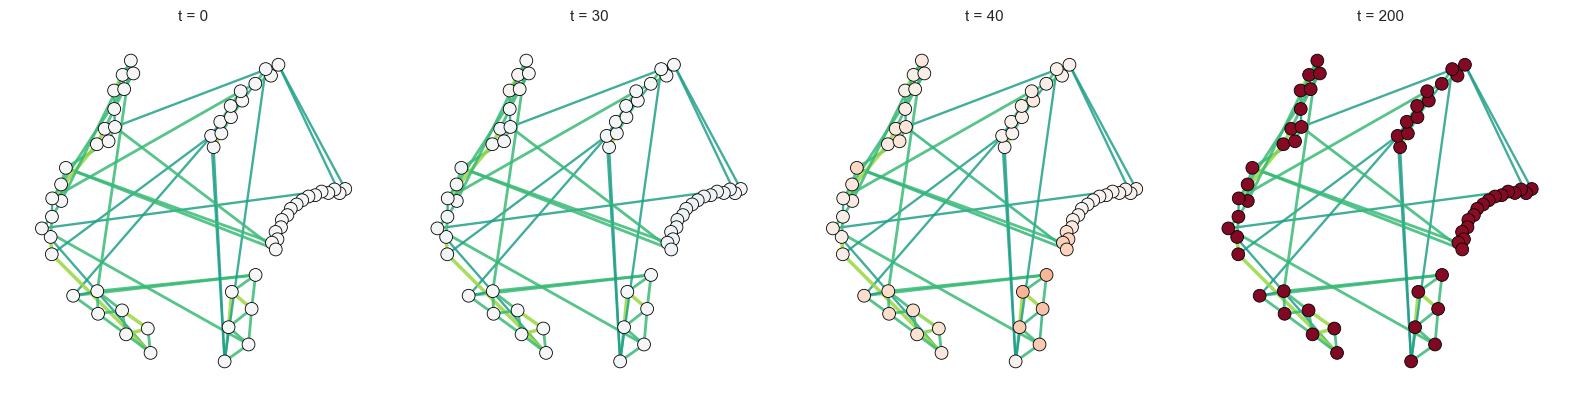

In [4]:
A_np = np.asarray(pop.A_adj)
layout = cluster_layout(A_np)

# Pick four representative snapshot indices
t_targets = [0, cfg.world.schedule_t_shift, cfg.world.schedule_t_shift + 10, T]
indices = [int(np.argmin(np.abs(snap_t - t))) for t in t_targets]

fig = static_strip(
    snapshots, A_np, layout,
    indices=indices,
    node_metric_key='theta_mean',
    node_size=85,
)
plt.show()


## What we've shown

1. **The v2 step composes correctly.** Build → step → snap runs without
   error; state arrays carry the right shapes; the JIT compiles.

2. **Paradigm persistence is visible.** $\bar\mu(t)$ tracks $\theta^*$
   tightly during the Newtonian phase, then *lags slowly* after the
   shift to $\theta^*_{\text{post}}$. This lag is the headline
   phenomenon — the community resists the paradigm change because the
   pre-shift posterior accumulated a precision $\bar\tau \gg 1$, which
   damps the influence of each new observation. The lag and recovery
   time are the primary observables for PDF E1.

3. **Posterior precision grows monotonically.** $\bar\tau$ never
   decreases in the absence of forgetting, exactly as PDF §5
   mechanism (iii) anticipates. This is Bayesian rigidity — and it is
   precisely what makes the post-shift recovery slow.

4. **Active inference policy adapts to confidence.** When $\bar\tau$ is
   low (early run; briefly post-shift when surprise spikes), agents pick
   higher $x$ to discriminate. As precision grows, the action
   distribution shifts toward cheap low-$x$ confirmations — agents who
   "already know the answer" stop running expensive experiments. This
   is the experiment-cost feedback loop PDF §4 highlights.

5. **Trust matrix specialises modestly.** The $\bar\gamma_{ii}$ vs
   $\bar\gamma_{ij}$ split (which v1 used to encode through the scalar
   $d_i$) is now a *learned* read-off of $\Gamma$. In a homogeneous
   population the differentiation is small; heterogeneous priors or
   $\lambda$ should amplify it (open question for the E1 notebook).

Next:

- `notebook 07` — PDF E1 (four-condition factorial: trust-learning ×
  posterior-forgetting). Headline metrics: adaptation lag, recovery
  time, hysteresis loop area under the "reversal" schedule.
- `notebook 08` — PDF E2 (topology comparison: WS-dense, WS-sparse,
  BA-hub).